# Shared model setup: splits + metrics

One shared definition of train/test split, CV folds, and evaluation
metrics, so 3 different models (built separately) stay comparable.

Each person then builds their own model in the "Your model here" section,
using the same `cv_folds`, `train_df` / `test_df`, and `regression_metrics`.


## 1. Load data

In [81]:
import numpy as np
import pandas as pd

DATA_PATH = r'..\data\model_input\df_model_input.csv'

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(1745282, 80)


,report_date,lm_positive,lm_negative,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio,ifo_business_climate,...,log_toas,log_empl,ncliGrowthThisYear,toas_growth,cash_growth,growth_volatility,firm_age,years_in_panel,naics_2digit,is_na_empl
0,2013-12-01,420,652,-0.216418,0.016592,0.018863,0.011103,0.001009,0.004038,100.4,...,7.595447,0.000000,NaN,NaN,NaN,NaN,36.0,0,31,1
1,2014-12-01,265,402,-0.205397,0.020557,0.014647,0.003769,0.001970,0.006167,98.2,...,7.592642,0.000000,-0.034155,-0.002801,0.127094,NaN,37.0,1,31,1
2,2016-12-01,352,677,-0.315841,0.021990,0.012566,0.005463,0.002117,0.005600,101.0,...,7.514275,5.003946,-0.832512,-0.075375,-0.493523,0.564524,39.0,2,31,0
3,2017-12-01,397,547,-0.158898,0.016656,0.015763,0.006186,0.002141,0.004342,104.7,...,7.512180,4.718499,-0.093514,-0.002093,-0.112008,0.444788,40.0,3,31,0
4,2018-12-01,359,513,-0.176606,0.020424,0.012030,0.006295,0.002518,0.004337,101.2,...,7.472122,4.795791,-0.119000,-0.039266,-0.331663,0.419497,41.0,4,31,0


# 1. Missing Data Imputation

In [82]:
# Imputation for Current Liability (culi)
def culi_deduction_impute(df: pd.DataFrame) -> pd.DataFrame:
    df_c = df.copy()
    culi_cols = ["loan", "cred", "ocli"]

    # Case 1: culi == 0 AND all components are 0 or NaN -> Fill component NaNs with 0.0
    mask_culi_zero = df_c["culi"] == 0
    mask_components_nonzero = (df_c[culi_cols].fillna(0.0) != 0).any(axis=1)

    mask_case_1 = mask_culi_zero & (~mask_components_nonzero)
    df_c.loc[mask_case_1, culi_cols] = df_c.loc[mask_case_1, culi_cols].fillna(0.0)

    # Case 2: culi == 0 BUT components != 0 -> Fill component NaNs with 0.0 & update culi
    mask_case_2 = mask_culi_zero & mask_components_nonzero
    df_c.loc[mask_case_2, culi_cols] = df_c.loc[mask_case_2, culi_cols].fillna(0.0)
    df_c.loc[mask_case_2, "culi"] = df_c.loc[mask_case_2, culi_cols].sum(axis=1)

    # Case 3a: culi is NaN, but 1 or more components exist
    # -> Fill missing components with 0.0 and compute culi = sum(loan + cred + ocli)
    mask_culi_nan = df_c["culi"].isna()
    has_components = df_c[culi_cols].notna().any(axis=1)
    mask_case_3a = mask_culi_nan & has_components

    df_c.loc[mask_case_3a, culi_cols] = df_c.loc[mask_case_3a, culi_cols].fillna(0.0)
    df_c.loc[mask_case_3a, "culi"] = df_c.loc[mask_case_3a, culi_cols].sum(axis=1)

    # Case 3b: culi exists & exactly 1 component is missing -> Deduce missing component
    # Deduce 'loan'
    m_loan = (df_c["culi"].notna()& df_c["loan"].isna()& df_c["cred"].notna()& df_c["ocli"].notna())
    df_c.loc[m_loan, "loan"] = (df_c.loc[m_loan, "culi"]- df_c.loc[m_loan, "cred"]- df_c.loc[m_loan, "ocli"])

    # Deduce 'cred'
    m_cred = (df_c["culi"].notna()& df_c["cred"].isna()& df_c["loan"].notna()& df_c["ocli"].notna())
    df_c.loc[m_cred, "cred"] = (df_c.loc[m_cred, "culi"]- df_c.loc[m_cred, "loan"]- df_c.loc[m_cred, "ocli"])

    # Deduce 'ocli'
    m_ocli = (df_c["culi"].notna()& df_c["ocli"].isna()& df_c["loan"].notna()& df_c["cred"].notna())
    df_c.loc[m_ocli, "ocli"] = (df_c.loc[m_ocli, "culi"]- df_c.loc[m_ocli, "loan"]- df_c.loc[m_ocli, "cred"])

    return df_c

# Execute on DataFrames
df = culi_deduction_impute(df)

# For Culi = 0, impute the components with 1 to prevent missing data
df['culi'] = df['culi'].replace(0.0, 1)

# Check if culi is still NaN or 0.0
culi_nan_count = df["culi"].isna().sum()
culi_zero_count = (df["culi"] == 0).sum()
total_rows = len(df)
nan_percentage = (culi_nan_count / total_rows) * 100
zero_percentage = (culi_zero_count / total_rows) * 100

print(f"Remaining NaN 'culi' rows: {culi_nan_count} ({nan_percentage:.2f}%)")
print(f"Remaining 0.0 'culi' rows: {culi_zero_count} ({zero_percentage:.2f}%)")

Remaining NaN 'culi' rows: 0 (0.00%)
Remaining 0.0 'culi' rows: 0 (0.00%)


In [83]:
# Imputation for Current Asset (cuas)

# Define Imputation Function for Current Assets (cuas)
def cuas_deduction_impute(df: pd.DataFrame) -> pd.DataFrame:

    df_c = df.copy()
    cuas_cols = ["stok", "debt", "ocas", "cash"]
    mask_cuas_zero = df_c["cuas"] == 0
    mask_components_nonzero = (df_c[cuas_cols].fillna(0.0) != 0).any(axis=1)

    # Case 1: cuas == 0 AND all components are 0 or NaN -> Fill component NaNs with 0.0
    mask_case_1 = mask_cuas_zero & (~mask_components_nonzero)
    df_c.loc[mask_case_1, cuas_cols] = df_c.loc[mask_case_1, cuas_cols].fillna(0.0)

    # Case 2: cuas == 0 BUT components != 0 -> Fill component NaNs with 0.0 & update cuas
    mask_case_2 = mask_cuas_zero & mask_components_nonzero
    df_c.loc[mask_case_2, cuas_cols] = df_c.loc[mask_case_2, cuas_cols].fillna(0.0)
    df_c.loc[mask_case_2, "cuas"] = df_c.loc[mask_case_2, cuas_cols].sum(axis=1)

    # Case 3a: cuas is NaN, but 1 or more components exist
    # -> Fill missing components with 0.0 and compute cuas = sum(stok + debt + ocas + cash)
    mask_cuas_nan = df_c["cuas"].isna()
    has_components = df_c[cuas_cols].notna().any(axis=1)
    mask_case_3a = mask_cuas_nan & has_components

    df_c.loc[mask_case_3a, cuas_cols] = df_c.loc[mask_case_3a, cuas_cols].fillna(0.0)
    df_c.loc[mask_case_3a, "cuas"] = df_c.loc[mask_case_3a, cuas_cols].sum(axis=1)

    # Case 3b: cuas exists & exactly 1 component is missing -> Deduce missing component
    # Deduce 'stok'
    m_stok = (df_c["cuas"].notna()& df_c["stok"].isna()& df_c["debt"].notna()& df_c["ocas"].notna()& df_c["cash"].notna())
    df_c.loc[m_stok, "stok"] = (df_c.loc[m_stok, "cuas"]- df_c.loc[m_stok, "debt"]- df_c.loc[m_stok, "ocas"]- df_c.loc[m_stok, "cash"])

    # Deduce 'debt'
    m_debt = (df_c["cuas"].notna()& df_c["debt"].isna()& df_c["stok"].notna()& df_c["ocas"].notna()& df_c["cash"].notna())
    df_c.loc[m_debt, "debt"] = (df_c.loc[m_debt, "cuas"]- df_c.loc[m_debt, "stok"]- df_c.loc[m_debt, "ocas"]- df_c.loc[m_debt, "cash"])

    # Deduce 'ocas'
    m_ocas = (df_c["cuas"].notna()& df_c["ocas"].isna()& df_c["stok"].notna()& df_c["debt"].notna()& df_c["cash"].notna())
    df_c.loc[m_ocas, "ocas"] = (df_c.loc[m_ocas, "cuas"]- df_c.loc[m_ocas, "stok"]- df_c.loc[m_ocas, "debt"]- df_c.loc[m_ocas, "cash"])

    # Deduce 'cash'
    m_cash = (df_c["cuas"].notna()& df_c["cash"].isna()& df_c["stok"].notna()& df_c["debt"].notna()& df_c["ocas"].notna())
    df_c.loc[m_cash, "cash"] = (df_c.loc[m_cash, "cuas"]- df_c.loc[m_cash, "stok"]- df_c.loc[m_cash, "debt"]- df_c.loc[m_cash, "ocas"])


    return df_c


# Execute on DataFrame
df = cuas_deduction_impute(df)

# Check remaining NaNs in cuas and stok
cuas_nan_count = df["cuas"].isna().sum()
stok_nan_count = df["stok"].isna().sum()
total_rows = len(df)

print(f"Remaining NaN 'cuas' rows: {cuas_nan_count} ({(cuas_nan_count / total_rows) * 100:.2f}%)")


Remaining NaN 'cuas' rows: 0 (0.00%)


In [84]:
# Impute stok with 0.0 when firms belong to categories which usually dont have stock (i.e. Banking)
zero_inventory_naics = [51, 52, 53, 54, 55, 56, 61, 62, 71, 81, 92]
df.loc[df['naics_2digit'].isin(zero_inventory_naics), 'stok'] = 0.0
updated_rows = df['naics_2digit'].isin(zero_inventory_naics).sum()
print(f"Assigned 'stok' = 0.0 for {updated_rows} rows.")

# Check remaining NaNs in stok
stok_missing_count = df['stok'].isna().sum()
stok_missing_pct = (stok_missing_count / len(df)) * 100
print(f"Missing values in 'stok': {stok_missing_count} rows ({stok_missing_pct:.2f}%)")

Assigned 'stok' = 0.0 for 732284 rows.
Missing values in 'stok': 11648 rows (0.67%)


In [85]:
# Recalculate ratios after imputations
df['leverage']            = df['ncli'] / df['toas']
df['gearing']             = (df['ncli'] + df['loan']) / df['shfd']
df['solvency']            = df['shfd'] / df['toas']
df['current_ratio']       = df['cuas'] / df['culi']
df['quick_ratio']         = (df['cuas'] - df['stok']) / df['culi']
df['cash_ratio']          = df['cash'] / df['toas']
df['inventory_share']     = df['stok'] / df['toas']
df['receivables_share']   = df['debt'] / df['toas']
df['working_capital_ratio'] = df['wkca'] / df['toas']
df['wkca'] = df['cuas'] - df['culi']

# 2. Feature Engineering

In [86]:
import gc
YEAR_COL = "closdate_year"
ID_COL = "idnr"
def safe_ratio(
    numerator: pd.Series,
    denominator: pd.Series,
    *,
    require_positive_denominator: bool = True,
) -> pd.Series:
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = numerator.notna() & denominator.notna()
    if require_positive_denominator:
        valid &= denominator > 0
    else:
        valid &= denominator != 0
    out = pd.Series(np.nan, index=numerator.index, dtype="float32")
    out.loc[valid] = (numerator.loc[valid] / denominator.loc[valid]).astype("float32")
    return out.replace([np.inf, -np.inf], np.nan)

# Sort once so all lagged firm features use only t and earlier observations.
df = df.sort_values([ID_COL, YEAR_COL]).copy()
firm_group = df.groupby(ID_COL, sort=False)
lag_year = firm_group[YEAR_COL].shift(1)
consecutive = (df[YEAR_COL] - lag_year).eq(1)

# -----------------------------------------------------------------------------
# Ratios based on documented balance-sheet identities. No data-driven
# winsorization is used, so test-year values cannot influence training values.
# -----------------------------------------------------------------------------
if {"cuas", "culi"}.issubset(df.columns):
    df["current_ratio_clean"] = safe_ratio(df["cuas"], df["culi"])
    df["log1p_current_ratio_clean"] = np.log1p(
        df["current_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"cuas", "stok", "culi"}.issubset(df.columns):
    quick_assets = df["cuas"] - df["stok"]
    df["quick_ratio_clean"] = safe_ratio(quick_assets, df["culi"])
    df["log1p_quick_ratio_clean"] = np.log1p(
        df["quick_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"shfd", "toas"}.issubset(df.columns):
    df["solvency_ratio_clean"] = safe_ratio(df["shfd"], df["toas"])

if {"ncli", "loan", "shfd"}.issubset(df.columns):
    # Gearing is undefined or difficult to interpret with non-positive equity.
    gearing_num = df["ncli"] + df["loan"]
    df["gearing_ratio_clean"] = safe_ratio(gearing_num, df["shfd"])
    df["log1p_gearing_ratio_clean"] = np.log1p(
        df["gearing_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"ncli", "culi", "toas"}.issubset(df.columns):
    df["liabilities_to_assets"] = safe_ratio(df["ncli"] + df["culi"], df["toas"])

if {"wkca", "toas"}.issubset(df.columns):
    df["working_capital_to_assets"] = safe_ratio(
        df["wkca"], df["toas"], require_positive_denominator=True
    )

if {"stok", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["stok"] >= 0) & (df["stok"] <= df["cuas"])
    df["inventory_share_current_assets"] = np.where(
        valid, df["stok"] / df["cuas"], np.nan
    ).astype("float32")

if {"debt", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["debt"] >= 0) & (df["debt"] <= df["cuas"])
    df["receivables_share_current_assets"] = np.where(
        valid, df["debt"] / df["cuas"], np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["cash"] >= 0) & (df["cash"] <= df["toas"])
    df["cash_to_assets"] = np.where(valid, df["cash"] / df["toas"], np.nan).astype("float32")

if {"fias", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["fias"] >= 0) & (df["fias"] <= df["toas"])
    df["fixed_assets_share"] = np.where(valid, df["fias"] / df["toas"], np.nan).astype("float32")

if {"ltdb", "ncli"}.issubset(df.columns):
    valid = (df["ncli"] > 0) & (df["ltdb"] >= 0) & (df["ltdb"] <= df["ncli"])
    df["ltdb_share_of_ncli"] = np.where(valid, df["ltdb"] / df["ncli"], np.nan).astype("float32")

# -----------------------------------------------------------------------------
# Stable changes in firm levels. These replace unstable cash percentage growth
# and make the time direction explicit.
# -----------------------------------------------------------------------------
if "log_toas" not in df.columns and "toas" in df.columns:
    df["log_toas"] = np.log1p(df["toas"].clip(lower=0)).astype("float32")
if "log_empl" not in df.columns and "empl" in df.columns:
    df["log_empl"] = np.log1p(df["empl"].clip(lower=0)).astype("float32")

if "log_toas" in df.columns:
    lag_log_toas = firm_group["log_toas"].shift(1)
    df["log_toas_change_clean"] = np.where(
        consecutive, df["log_toas"] - lag_log_toas, np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    lag_cash = firm_group["cash"].shift(1)
    lag_toas = firm_group["toas"].shift(1)
    valid = consecutive & lag_toas.gt(0)
    df["cash_change_to_lagged_assets"] = np.where(
        valid, (df["cash"] - lag_cash) / lag_toas, np.nan
    ).astype("float32")

if "ncliGrowthThisYear" in df.columns:
    rolling_volatility = (
        df.groupby(ID_COL, sort=False)["ncliGrowthThisYear"]
          .rolling(window=3, min_periods=2)
          .std()
          .reset_index(level=0, drop=True)
    )
    df["ncli_growth_volatility_3y"] = rolling_volatility.astype("float32")

# -----------------------------------------------------------------------------
# Macro transformations.
# Confidence balances can cross zero, so use first differences.
# Positive indices use percentage changes calculated from annual levels.
# -----------------------------------------------------------------------------
BALANCE_LEVELS = [
    "de_construction_confidence",
    "de_consumer_confidence",
    "de_industry_confidence",
    "de_retail_confidence",
    "de_services_confidence",
]
POSITIVE_INDEX_LEVELS = [
    "de_economic_sentiment_index",
    "de_employment_expectations_index",
    "ifo_business_climate",
    "ifo_business_expectations",
    "ifo_business_situation",
]

available_macro_levels = [
    c for c in BALANCE_LEVELS + POSITIVE_INDEX_LEVELS if c in df.columns
]
if available_macro_levels:
    annual_macro = (
        df.groupby(YEAR_COL, sort=True)[available_macro_levels]
          .median(numeric_only=True)
          .sort_index()
    )

    for col in [c for c in BALANCE_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_change_clean"
        year_values = annual_macro[col].diff()
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

    for col in [c for c in POSITIVE_INDEX_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_pct_change_clean"
        current = annual_macro[col]
        previous = current.shift(1)
        year_values = ((current / previous) - 1).where((current > 0) & (previous > 0))
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

# -----------------------------------------------------------------------------
# Text counts are used only if a document-length variable exists. Otherwise,
# raw lm_positive/lm_negative counts are omitted and polarity/ratios are used.
# -----------------------------------------------------------------------------
TOKEN_COUNT_CANDIDATES = [
    "token_count", "n_tokens", "word_count", "total_words", "document_length"
]
token_count_col = next((c for c in TOKEN_COUNT_CANDIDATES if c in df.columns), None)
if token_count_col is not None:
    for source, target in [
        ("lm_positive", "lm_positive_frequency"),
        ("lm_negative", "lm_negative_frequency"),
    ]:
        if source in df.columns:
            df[target] = safe_ratio(df[source], df[token_count_col])
    print(f"Normalized sentiment counts using: {token_count_col}")
else:
    print("No document-length column found: raw positive/negative counts will be omitted.")

# Replace any remaining infinities and downcast new floating-point columns.
float64_cols = df.select_dtypes(include="float64").columns
df[float64_cols] = df[float64_cols].astype("float32")
df.replace([np.inf, -np.inf], np.nan, inplace=True)

del firm_group, lag_year, consecutive
gc.collect()

No document-length column found: raw positive/negative counts will be omitted.


2577

# 3. Config


In [87]:
df['report_year'] = pd.to_datetime(df['report_date']).dt.year
df.drop(columns=['report_date'], inplace=True)
df.head(5)

,lm_positive,lm_negative,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio,ifo_business_climate,ifo_business_situation,...,de_consumer_confidence_change_clean,de_industry_confidence_change_clean,de_retail_confidence_change_clean,de_services_confidence_change_clean,de_economic_sentiment_index_pct_change_clean,de_employment_expectations_index_pct_change_clean,ifo_business_climate_pct_change_clean,ifo_business_expectations_pct_change_clean,ifo_business_situation_pct_change_clean,report_year
0,420,652,-0.216418,0.016592,0.018863,0.011103,0.001009,0.004038,100.400002,99.099998,...,5.4,10.6,9.5,4.6,0.081466,0.011550,0.052411,0.068277,0.035528,2013
1,265,402,-0.205397,0.020557,0.014647,0.003769,0.001970,0.006167,98.199997,98.400002,...,-0.1,-4.7,-5.0,-2.4,-0.030132,-0.028544,-0.021912,-0.035398,-0.007064,2014
2,352,677,-0.315841,0.021990,0.012566,0.005463,0.002117,0.005600,101.000000,101.800003,...,1.5,5.5,-1.5,0.7,0.028195,0.020947,0.002979,-0.005952,0.011928,2016
3,397,547,-0.158898,0.016656,0.015763,0.006186,0.002141,0.004342,104.699997,107.099998,...,1.7,12.0,4.1,1.2,0.050274,0.042819,0.036634,0.022954,0.052063,2017
4,359,513,-0.176606,0.020424,0.012030,0.006295,0.002518,0.004337,101.199997,105.300003,...,-2.2,-10.6,-5.1,0.1,-0.040905,-0.010265,-0.033429,-0.050732,-0.016807,2018


In [88]:
YEAR_COL = "report_year"          
TARGET   = "ncliGrowthNextYear"  

EXCLUDE_COLS = ['idnr', 'name', # identifiers
                 'dateinc', # already used in firm age calculation
                 'naics_core_code', # already used in naics_2digit - naics_core_code is a more detailed industry code, but we want to avoid too many dummies. So we use naics_2digit instead. the first 2 digits already represent a broad sector (manufacturing, construction, retail, etc.)
                 'closdate_year' # this is the same year information as report_date
                 ] 

FEATURE_COLS = df.columns.difference([YEAR_COL, TARGET, *EXCLUDE_COLS]).tolist()

CATEGORY_COLS = ['naics_2digit', 'type']  # Categorical columns to be one-hot encoded

MIN_TRAIN_YEARS = 5     # first fold: train on this many years, test on the next
TEST_YEARS = [2020, 2021, 2022, 2023]   

In [89]:
df['naics_2digit'].unique()

array([31, 53, 23, 42, 55, 44, 32, 54, 81, 62, 51, 52, 33, 48, 45, 72, 56,
       22, 71, 21, 11, 61, 49, 92])

Reasoning of set min_train_year = 5:
- Early years have far fewer, differently-composed firms (panel coverage
expanded over time)
- If a CV fold trains only on those sparse years, its
score reflects a coverage-composition shift, not real forecasting
difficulty.
- `MIN_TRAIN_YEARS = 5` is a starting recommendation: it dilutes the sparse
years to roughly ~15-20% of fold 1's training set 

In [90]:
year_counts = df[YEAR_COL].value_counts().sort_index()
print(year_counts)

years_sorted = sorted(year_counts.index)

# Adjust this to wherever coverage visibly stabilizes in the printout above
SPARSE_CUTOFF_YEAR = 2013

print(f"\n{'min_train_years':>16} {'first_test_year':>16} {'sparse_share':>14}")
for m in range(4, 10):
    if m >= len(years_sorted):
        continue
    train_years = years_sorted[:m]
    total = sum(year_counts[y] for y in train_years)
    sparse = sum(year_counts[y] for y in train_years if y < SPARSE_CUTOFF_YEAR)
    share = sparse / total if total else float("nan")
    first_test_year = years_sorted[m]
    print(f"{m:>16} {first_test_year:>16} {share:>13.1%}")


report_year
2010     13132
2011     12950
2012     21695
2013     39951
2014    138297
2015    145276
2016    149169
2017    190184
2018    201605
2019    201110
2020    219759
2021    225653
2022    184816
2023      1685
Name: count, dtype: int64

 min_train_years  first_test_year   sparse_share
               4             2014         54.5%
               5             2015         21.1%
               6             2016         12.9%
               7             2017          9.2%
               8             2018          6.7%
               9             2019          5.2%


Note: Reasoning about using test years from 2020, explicitly separate the COVID pandemic on the test set only, because:
- This measures "if an unprecedented shock hits, and my model has never seen anything like it, how badly does it break?" That's actually the most realistic deployment scenario - a bank planning financing programs can't guarantee the next crisis looks like something already in its training data. This is the harder, more honest test.

# 4. Fold + metric functions


In [91]:
def rolling_origin_folds(years, min_train_years=4, max_year=None):
    """Expanding-window folds: train on years[:i], test on years[i].

    Example with years 2013..2020, min_train_years=4:
        Fold 1: train <=2016, test 2017
        Fold 2: train <=2017, test 2018
        Fold 3: train <=2018, test 2019
        Fold 4: train <=2019, test 2020
    Only include years in the training set
    """
    years = sorted(set(years))
    return [
        (years[:i], years[i])
        for i in range(min_train_years, len(years))
    ]


def regression_metrics(y_true, y_pred, baseline_value):
    """RMSE, MAE, R2_oos vs. a naive baseline (e.g. train-set mean).

    R2_oos > 0 means the model beats "always predict the baseline value"
    on this data. Use the SAME baseline_value (train-set mean) for every
    model so the comparison is apples-to-apples
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]

    if len(yt) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2_oos": np.nan, "n": 0}

    err = yt - yp
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = np.sum(err ** 2)
    ss_baseline = np.sum((yt - baseline_value) ** 2)
    r2_oos = float(1 - ss_res / ss_baseline) if ss_baseline > 0 else np.nan

    return {"RMSE": rmse, "MAE": mae, "R2_oos": r2_oos, "n": int(mask.sum())}


# 5. Train/test split + CV folds

- 4.1. Train/test split:
    - Train set: 2012-2019
    - Test set: 2020-2023
    
    Test set is set aside and never touched during tuning
- 4.2. Create multiple folds for cross validation, built from train set only, so a test years can never leak into folds.


In [92]:
# Train/test split
train_df = df[~df[YEAR_COL].isin(TEST_YEARS)]
train_df = train_df[train_df[YEAR_COL] < min(TEST_YEARS)]   # drop anything before test block too, if present
test_df  = df[df[YEAR_COL].isin(TEST_YEARS)]
baseline_value = train_df[TARGET].mean()   # SAME baseline for every model

print(f"train: {train_df.shape}, test {TEST_YEARS}: {test_df.shape}")


train: (1113369, 107), test [2020, 2021, 2022, 2023]: (631913, 107)


In [93]:
min(df[YEAR_COL]), max(df[YEAR_COL]), min(train_df[YEAR_COL]), max(train_df[YEAR_COL]), min(test_df[YEAR_COL]), max(test_df[YEAR_COL])

(2010, 2023, 2010, 2019, 2020, 2023)

In [94]:
years = train_df[YEAR_COL].unique()

cv_folds = rolling_origin_folds(years, min_train_years=MIN_TRAIN_YEARS)

for train_years, test_year in cv_folds:
    print(f"train <= {max(train_years)} ({len(train_years)} yrs)  ->  test {test_year}")


train <= 2014 (5 yrs)  ->  test 2015
train <= 2015 (6 yrs)  ->  test 2016
train <= 2016 (7 yrs)  ->  test 2017
train <= 2017 (8 yrs)  ->  test 2018
train <= 2018 (9 yrs)  ->  test 2019


# 6. Meta Model


In [95]:
def present(columns: list[str]) -> list[str]:
    return [c for c in columns if c in df.columns]

CATEGORY_COLS = present(["naics_2digit", "type"])

FIRM_NUMERIC_CANDIDATES = [
    "log_toas",
    "log_empl",                 # raw empl is intentionally omitted
    "firm_age",
    "years_in_panel",
    "is_na_empl",
    "ncliGrowthThisYear",
    "log_toas_change_clean",
    "cash_change_to_lagged_assets",
    "ncli_growth_volatility_3y",
    "log1p_current_ratio_clean",
    "log1p_quick_ratio_clean",
    "solvency_ratio_clean",
    "log1p_gearing_ratio_clean",
    "liabilities_to_assets",
    "working_capital_to_assets",
    "inventory_share_current_assets",
    "receivables_share_current_assets",
    "cash_to_assets",
    "fixed_assets_share",
    "ltdb_share_of_ncli",
]
FIRM_FEATURES = present(FIRM_NUMERIC_CANDIDATES) + CATEGORY_COLS

SURVEY_LEVEL_FEATURES = present(BALANCE_LEVELS + POSITIVE_INDEX_LEVELS)
SURVEY_CHANGE_FEATURES = present(
    [f"{c}_change_clean" for c in BALANCE_LEVELS]
    + [f"{c}_pct_change_clean" for c in POSITIVE_INDEX_LEVELS]
)
SURVEY_FEATURES = SURVEY_LEVEL_FEATURES + SURVEY_CHANGE_FEATURES

TEXT_FEATURES = present([
    "lm_polarity",
    "uncertainty_ratio",
    "litigious_ratio",
    "constraining_ratio",
    "strong_modal_ratio",
    "weak_modal_ratio",
    "lm_positive_frequency",
    "lm_negative_frequency",
])

FEATURE_SETS = {
    "firm": FIRM_FEATURES,
    "firm_survey": list(dict.fromkeys(FIRM_FEATURES + SURVEY_FEATURES)),
    "firm_survey_text": list(dict.fromkeys(FIRM_FEATURES + SURVEY_FEATURES + TEXT_FEATURES)),
}

for name, cols in FEATURE_SETS.items():
    if not cols:
        raise ValueError(f"Feature set {name!r} is empty.")
    print(f"{name:>18}: {len(cols):>3} columns")
    print(cols)

# Explicit leakage / redundancy guard.
FORBIDDEN_FEATURES = {
    TARGET, YEAR_COL, "year", ID_COL, "naics_core_code", "empl",
    "cash_growth", "toas_growth",
    "de_construction_confidence_growth", "de_consumer_confidence_growth",
    "de_industry_confidence_growth", "de_retail_confidence_growth",
    "de_services_confidence_growth",
    "lm_positive", "lm_negative",
}
for set_name, cols in FEATURE_SETS.items():
    overlap = sorted(set(cols).intersection(FORBIDDEN_FEATURES))
    if overlap:
        raise AssertionError(f"Forbidden features in {set_name}: {overlap}")


              firm:  22 columns
['log_toas', 'log_empl', 'firm_age', 'years_in_panel', 'is_na_empl', 'ncliGrowthThisYear', 'log_toas_change_clean', 'cash_change_to_lagged_assets', 'ncli_growth_volatility_3y', 'log1p_current_ratio_clean', 'log1p_quick_ratio_clean', 'solvency_ratio_clean', 'log1p_gearing_ratio_clean', 'liabilities_to_assets', 'working_capital_to_assets', 'inventory_share_current_assets', 'receivables_share_current_assets', 'cash_to_assets', 'fixed_assets_share', 'ltdb_share_of_ncli', 'naics_2digit', 'type']
       firm_survey:  42 columns
['log_toas', 'log_empl', 'firm_age', 'years_in_panel', 'is_na_empl', 'ncliGrowthThisYear', 'log_toas_change_clean', 'cash_change_to_lagged_assets', 'ncli_growth_volatility_3y', 'log1p_current_ratio_clean', 'log1p_quick_ratio_clean', 'solvency_ratio_clean', 'log1p_gearing_ratio_clean', 'liabilities_to_assets', 'working_capital_to_assets', 'inventory_share_current_assets', 'receivables_share_current_assets', 'cash_to_assets', 'fixed_asset

### 6.1 Load pre-trained models

In [96]:
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.base import clone

MODEL_PATHS = {
    'firm': {
        'RF': r'..\model\saved_models\firm_rf_model.pkl',
        'XGB': r'..\model\saved_models\firm_xgboost_model.pkl',
        'NN': r'..\model\saved_models\mlp_final_model_firm.pkl'
    },
    'firm_survey': {
        'RF': r'..\model\saved_models\firm_survey_rf_model.pkl',
        'XGB': r'..\model\saved_models\firm_survey_xgboost_model.pkl',
        'NN': r'..\model\saved_models\mlp_final_model_firm_survey.pkl'
    },
    'firm_survey_text': {
        'RF': r'..\model\saved_models\firm_survey_text_rf_model.pkl',
        'XGB': r'..\model\saved_models\firm_survey_text_xgboost_model.pkl',
        'NN': r'..\model\saved_models\mlp_final_model_firm_survey_text.pkl'
    }
}

baseline_val = train_df[TARGET].mean()

In [97]:
def smart_load_model(path):
    obj = joblib.load(path)
    
    # If the loaded object is a dictionary
    if isinstance(obj, dict):
        for key, value in obj.items():
            # Identify the machine learning model: it must have 'fit' and 'predict' methods
            if hasattr(value, 'fit') and hasattr(value, 'predict'):
                return value
        raise ValueError(f"Could not find a valid model inside the dictionary of file: {path}")
        
    # If the .pkl file is already a direct model object
    return obj


In [98]:

def get_series_format(df, col, format_type):
    if format_type == 'Float':
        return df[col].astype(float)
    elif format_type == 'Int64':
        return df[col].astype('Int64')
    elif format_type == 'String':
        return df[col].astype(str)
    elif format_type == 'Clean_String':
        return df[col].apply(
            lambda x: str(int(float(x))) if pd.notna(x) and str(x).lower() != 'nan' else np.nan
        )

def auto_align_all_data(train_data, test_data, features, xgb_model):
    train_fixed = train_data.copy()
    test_fixed = test_data.copy()
    
    print("Auto-fixing 'type' column...")
    if 'type' in train_fixed.columns:
        train_fixed['type'] = train_fixed['type'].astype(str).astype('category')
        test_fixed['type'] = pd.Categorical(
            test_fixed['type'].astype(str), 
            categories=train_fixed['type'].cat.categories
        )
        
    print("Auto-fixing 'naics_2digit' column...")
    if 'naics_2digit' in train_fixed.columns:
        options = ['Float', 'Int64', 'String', 'Clean_String']
        success = False
        
        for opt in options:

            train_temp = get_series_format(train_fixed, 'naics_2digit', opt).astype('category')
            
            test_raw = get_series_format(test_fixed, 'naics_2digit', opt)
            test_temp = pd.Categorical(test_raw, categories=train_temp.cat.categories)
            
            train_fixed['naics_2digit'] = train_temp
            test_fixed['naics_2digit'] = test_temp
            
            try:
                xgb_model.predict(test_fixed[features].iloc[[0]])
                print(f"XGBoost accepts format: {opt}")
                success = True
                break
            except Exception as e:
                # If it fails, silently move to the next format
                continue
                
        if not success:
            print("Auto-fix failed. Please check data manually.")
            
    return train_fixed, test_fixed


xgb_firm_path = None
for name, path in MODEL_PATHS['firm'].items():
    if 'xgb' in name.lower():
        xgb_firm_path = path
        break

xgb_model = smart_load_model(xgb_firm_path)
current_features = FEATURE_SETS['firm']

train_df, test_df = auto_align_all_data(train_df, test_df, current_features, xgb_model)
print("\nData perfectly aligned! You can now run your predictions safely.")

Auto-fixing 'type' column...
Auto-fixing 'naics_2digit' column...
XGBoost accepts format: String

Data perfectly aligned! You can now run your predictions safely.


#### Check Model Errors Correlation

=== CHECKING ERROR CORRELATION FOR: FIRM ===
Loading and predicting for RF...


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Loading and predicting for XGB...
Loading and predicting for NN...


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


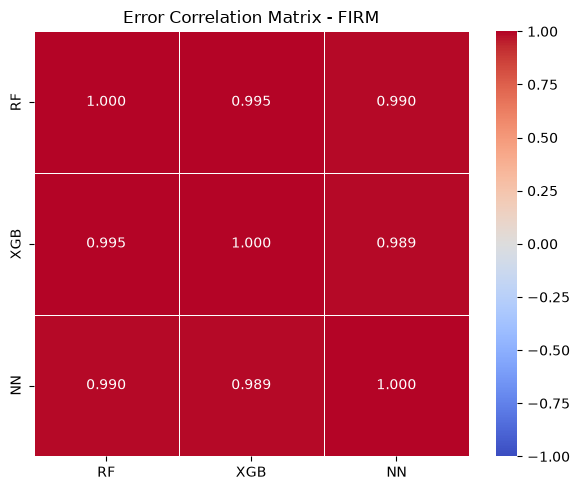



=== CHECKING ERROR CORRELATION FOR: FIRM_SURVEY ===
Loading and predicting for RF...


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Loading and predicting for XGB...
Loading and predicting for NN...


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


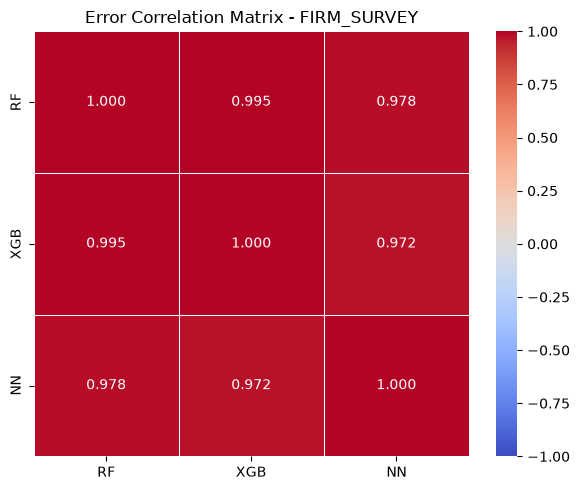



=== CHECKING ERROR CORRELATION FOR: FIRM_SURVEY_TEXT ===
Loading and predicting for RF...


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Loading and predicting for XGB...
Loading and predicting for NN...


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


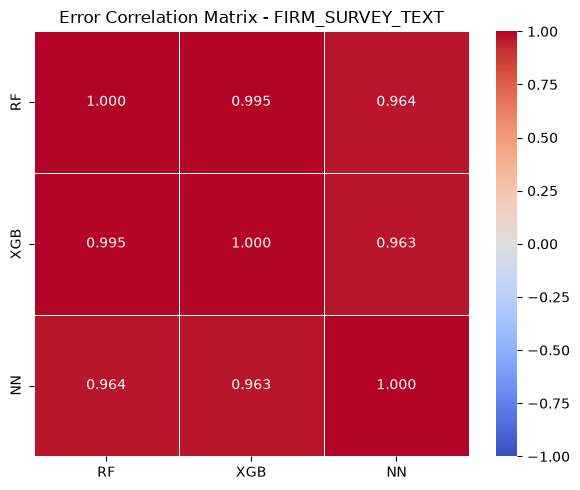

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

def check_error_correlation(set_name, current_features, model_paths_dict, test_data):
    print(f"=== CHECKING ERROR CORRELATION FOR: {set_name.upper()} ===")
    

    X_test = test_data[current_features]
    y_true = test_data[TARGET]
    
    models_to_check = list(model_paths_dict.keys())
    errors_df = pd.DataFrame(index=test_data.index)
    
    for model_name in models_to_check:
        print(f"Loading and predicting for {model_name}...")
        trained_model = smart_load_model(model_paths_dict[model_name])
        
        preds = trained_model.predict(X_test)
        errors_df[model_name] = y_true - preds

    corr_matrix = errors_df.corr()
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", linewidths=0.5)
    plt.title(f"Error Correlation Matrix - {set_name.upper()}")
    plt.tight_layout()
    plt.show()
    
    return corr_matrix

for set_name, current_features in FEATURE_SETS.items():
    current_model_paths = MODEL_PATHS[set_name]
    corr = check_error_correlation(set_name, current_features, current_model_paths, test_df)
    print("\n")

### 6.2 Out-of-Fold predictions and targets for the Meta-Model

In [50]:
def generate_oof_predictions(current_features, current_model_paths, cv_folds, train_df):
    """
    Retrains the models on each fold using clone() to generate unbiased 
    Out-of-Fold (OOF) predictions for the Meta-Model.
    """
    models_to_ensemble = list(current_model_paths.keys())
    oof_predictions = pd.DataFrame(index=train_df.index, columns=models_to_ensemble)
    oof_targets = pd.Series(index=train_df.index, dtype=float)
    
    base_models = {name: smart_load_model(path) for name, path in current_model_paths.items()}
    
    for fold_idx, (train_years, test_year) in enumerate(cv_folds):
        fold_train = train_df[train_df[YEAR_COL].isin(train_years)]
        fold_valid = train_df[train_df[YEAR_COL] == test_year]
        
        X_train = fold_train[current_features]
        y_train = fold_train[TARGET]
        X_valid = fold_valid[current_features]
        y_valid = fold_valid[TARGET]
        
        oof_targets.loc[fold_valid.index] = y_valid
        
        for model_name in models_to_ensemble:
            # Creates a fresh, untrained estimator with the same parameters
            model_clone = clone(base_models[model_name])
            
            # Fit on the fold's training data and predict on validation data
            model_clone.fit(X_train, y_train)
            oof_predictions.loc[fold_valid.index, model_name] = model_clone.predict(X_valid)

    valid_mask = oof_predictions.notna().all(axis=1)
    return oof_predictions[valid_mask], oof_targets[valid_mask]

### 6.3 Train the meta model

In [51]:
def train_meta_model(oof_preds_clean, oof_targets_clean, models_to_ensemble):
    """Trains the Linear Regression Meta-Model using non-negative constraints."""
    meta_model = LinearRegression(positive=True)
    meta_model.fit(oof_preds_clean, oof_targets_clean)
    
    print("Meta-Model Coefficients:")
    for name, coef in zip(models_to_ensemble, meta_model.coef_):
        print(f"Beta for {name}: {coef:.4f}")
    print(f"Intercept (Alpha): {meta_model.intercept_:.4f}")
    
    return meta_model

### 6.4 Predict on Test Set

In [52]:
def predict_test_set(meta_model, current_features, current_model_paths, test_df):
    """
    Predicts the final hold-out test set using the ORIGINAL .pkl files 
    (which were trained on 100% of the training data).
    """
    models_to_ensemble = list(current_model_paths.keys())
    test_predictions = pd.DataFrame(index=test_df.index, columns=models_to_ensemble)
    X_test = test_df[current_features]

    for model_name in models_to_ensemble:
        trained_model = smart_load_model(current_model_paths[model_name])
        test_predictions[model_name] = trained_model.predict(X_test)

    return meta_model.predict(test_predictions)

### 6.5 Model Evaluation

In [53]:
def evaluate_results(set_name, final_test_preds, test_df, baseline_val):
    """Calculates evaluation metrics broken down by Year and Industry."""
    results_list = []
    
    eval_df = pd.DataFrame({
        'y_true': test_df[TARGET],
        'y_pred': final_test_preds,
        'year': test_df[YEAR_COL],
        'industry': test_df['naics_2digit']
    })

    # Evaluate by year
    for year, group_data in eval_df.groupby('year'):
        metrics = regression_metrics(group_data['y_true'], group_data['y_pred'], baseline_val)
        metrics.update({'group': year, 'group_type': 'year', 'feature_set': set_name})
        results_list.append(metrics)

    # Evaluate by industry
    for industry, group_data in eval_df.groupby('industry'):
        metrics = regression_metrics(group_data['y_true'], group_data['y_pred'], baseline_val)
        metrics.update({'group': industry, 'group_type': 'industry', 'feature_set': set_name})
        results_list.append(metrics)
        
    return results_list

### 6.6 Execution Loop

In [ ]:
# OOF predictions
oof_results_dict = {}

for set_name, current_features in FEATURE_SETS.items():
    print(f"\nProcessing OOF for: {set_name.upper()}...")
    
    current_model_paths = MODEL_PATHS[set_name]
    models_to_ensemble = list(current_model_paths.keys())
    
    oof_preds_clean, oof_targets_clean = generate_oof_predictions(
    current_features, current_model_paths, cv_folds, train_df)
    
    oof_results_dict[set_name] = {
        'preds': oof_preds_clean,
        'targets': oof_targets_clean,
        'models_to_ensemble': models_to_ensemble
    }
    print(f"OOF generated successfully for {set_name.upper()}.")


Processing OOF for: FIRM...


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.war

In [ ]:
# Train Meta-Models using OOF predictions
meta_models_dict = {}

for set_name in FEATURE_SETS.keys():
    print(f"\nTraining Meta-Model for: {set_name.upper()}...")
    
    oof_preds_clean = oof_results_dict[set_name]['preds']
    oof_targets_clean = oof_results_dict[set_name]['targets']
    models_to_ensemble = oof_results_dict[set_name]['models_to_ensemble']
    
    meta_model = train_meta_model(
        oof_preds_clean, oof_targets_clean, models_to_ensemble
    )
    
    meta_models_dict[set_name] = meta_model

In [ ]:
# Predict on the final hold-out test set using the trained Meta-Models
final_test_preds_dict = {}

for set_name, current_features in FEATURE_SETS.items():
    print(f"\nPredicting Test Set for: {set_name.upper()}...")
    
    current_model_paths = MODEL_PATHS[set_name]
    models_to_ensemble = oof_results_dict[set_name]['models_to_ensemble']
    meta_model = meta_models_dict[set_name]
    
    final_test_preds = predict_test_set(
        meta_model, current_features, models_to_ensemble, current_model_paths, cv_folds, test_df
    )
    
    final_test_preds_dict[set_name] = final_test_preds
    print(f"Prediction successful for {set_name.upper()}.")

In [ ]:
# Model performance evaluation on the final hold-out test set
all_results_list = []

for set_name in FEATURE_SETS.keys():
    print(f"Evaluating: {set_name.upper()}...")
    
    final_test_preds = final_test_preds_dict[set_name]
    
    current_set_metrics = evaluate_results(
        set_name, final_test_preds, test_df, baseline_val
    )
    all_results_list.extend(current_set_metrics)

print("\nProcessing summary tables...")
results_df = pd.DataFrame(all_results_list)
cols_order = ['feature_set', 'group_type', 'group', 'RMSE', 'MAE', 'R2_oos', 'n']
results_df = results_df[cols_order]

results_df_clean = results_df[results_df['group'] != 2023].copy()
year_results = results_df_clean[results_df_clean["group_type"] == "year"].copy()
industry_results = results_df_clean[results_df_clean["group_type"] == "industry"].copy()

print("\nRESULTS BY YEAR")
print(year_results.to_string(index=False))

print("\nRESULTS BY INDUSTRY")
print(industry_results.to_string(index=False))